## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import types
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import pylab as pl
import numpy as np
import scipy as sp
from scipy import stats
import yaml

from caa_model.config import *
from caa_model.models import base_model, disp_classic, sisp_constrained, disp_staggered
from caa_model.models.results import *
from caa_model.models.base_model import BaseDDM
from caa_model.models.disp_classic import DISPClassicDDM
from caa_model.models.sisp_constrained import SISPConstrainedDDM
from caa_model.models.disp_staggered import DISPStaggeredDDM

## Setup

In [3]:
data = base_model.DATA

caa_cfg = CAAConfig(
    delta_t=0.025,
    nr_ssteps=8192,
    nr_samples=10000,
    max_t=8.0,
)

def display_comparison(evals: list[ModelEvaluation]):
    """Renders a side-by-side comparison Markdown table for multiple ModelEvaluations."""
    methods = " | ".join([f"`{e.method.upper()}`" for e in evals])
    align = " | ".join(["---:"] * len(evals))
    
    trials = " | ".join([f"{e.n_trials:,}" for e in evals])
    params = " | ".join([f"{e.n_params}" for e in evals])
    nll    = " | ".join([f"{e.nll:.2f}" for e in evals])
    aic    = " | ".join([f"**{e.aic:.2f}**" for e in evals])
    bic    = " | ".join([f"**{e.bic:.2f}**" for e in evals])

    md_table = f"""
### Model Evaluation Comparison

| Metric | {methods} |
| :--- | {align} |
| **Trials ($N$)** | {trials} |
| **Parameters ($k$)** | {params} |
| **Negative Log-Likelihood** | {nll} |
| **AIC** | {aic} |
| **BIC** | {bic} |
"""
    display(Markdown(md_table))

def fit_methods(model, methods, **kwargs):
    return {m: model.fit(method=m, **kwargs) for m in methods}

methods = ["qmle", "qmpe"]

In [4]:
def compute_gof_lure(self, model_params, data=base_model.DATA, method="qmpe", use_chisq=False):
    """Overrides the base loss function to ONLY compute loss for Lures."""
    try:
        target_params, lure_params = self.split_params(model_params)

        # Only extract the new (lure) data
        new_data = [data.rem_fa.rt, data.know_fa.rt, data.CR.rt, data.rem_fa.conf, data.know_fa.conf]

        # Compute GOF ONLY for the lures
        gof_lure = self.compute_model_gof(lure_params, *new_data, method=method, use_chisq=use_chisq)

        if pl.isnan(gof_lure) or pl.isinf(gof_lure):
            return 1e9
        return gof_lure
    except Exception:
        return 1e9


def compute_gof_target(self, model_params, data=base_model.DATA, method="qmpe", use_chisq=False):
    """Overrides the base loss function to ONLY compute loss for Targets."""
    try:
        target_params, lure_params = self.split_params(model_params)

        # Only extract the old (target) data
        old_data = [data.rem_hit.rt, data.know_hit.rt, data.miss.rt, data.rem_hit.conf, data.know_hit.conf]

        # Compute GOF ONLY for the targets
        gof_target = self.compute_model_gof(target_params, *old_data, method=method, use_chisq=use_chisq)

        if pl.isnan(gof_target) or pl.isinf(gof_target):
            return 1e9
        return gof_target
    except Exception:
        return 1e9


## Lure Only

### SISP Constrained

In [ ]:
class SISPConstrainedLuresOnly(SISPConstrainedDDM):
    Params = SISPConstrainedDDM.Params

    def compute_gof_all(self, model_params, data=base_model.DATA, method="qmpe", use_chisq=False):
        """Overrides the base loss function to ONLY compute loss for Lures."""
        try:
            target_params, lure_params = self.split_params(model_params)

            # Only extract the new (lure) data
            new_data = [data.rem_fa.rt, data.know_fa.rt, data.CR.rt, data.rem_fa.conf, data.know_fa.conf]

            # Compute GOF ONLY for the lures
            gof_lure = self.compute_model_gof(lure_params, *new_data, method=method, use_chisq=use_chisq)

            if pl.isnan(gof_lure) or pl.isinf(gof_lure):
                return 1e9
            return gof_lure
        except Exception:
            return 1e9


sisp_constrained_lure_model = SISPConstrainedLuresOnly(
    config=caa_cfg,
    nr_threads=1,
)

original_bounds = sisp_constrained.param_bounds
locked_lower = original_bounds[0]
locked_upper = original_bounds[1]._replace(
    mu_t=locked_lower.mu_t,
    z0_t=locked_lower.z0_t,
    sigma_z0=locked_lower.sigma_z0,
)
param_bounds = (locked_lower, locked_upper)

n_params = 8
n_trials = (
    len(data.CR.rt)
    + len(data.rem_fa.rt)
    + len(data.know_fa.rt)
)

# Optimize over entire data
# sisp_constrained_lure_opt = fit_methods(
#     sisp_constrained_lure_model,
#     methods,
#     param_bounds=param_bounds,
#     nr_workers=7,
# )

# Nonnegative mu
sisp_constrained_lure_opt = {
    'qmle': SISPConstrainedLuresOnly.Params(c=np.float64(1.549972892371577), mu_t=np.float64(0.00011188888867321833), mu_l=np.float64(0.0009036473403820572), d=np.float64(0.4159760420101952), tc_bound=np.float64(0.038689999160129135), r_bound_offset=np.float64(1.4652590382614434), z0_t=np.float64(-1.9972568542981275), z0_l=np.float64(-0.4365810311173086), t_post=np.float64(0.5902986903539058), sigma_z0=np.float64(9.959347977622573e-11), t0=np.float64(0.7150708213250883)),
    'qmpe': SISPConstrainedLuresOnly.Params(c=np.float64(1.5929513561719015), mu_t=np.float64(-0.00019185927091752643), mu_l=np.float64(6.14552258337789e-05), d=np.float64(0.45194556406566005), tc_bound=np.float64(0.010718740897551211), r_bound_offset=np.float64(1.4910979942266325), z0_t=np.float64(-2.0206751502811713), z0_l=np.float64(-0.42602237659361086), t_post=np.float64(0.5470781636047688), sigma_z0=np.float64(1.0320486213664483e-10), t0=np.float64(0.7243959170301364))
}

# Negative mu
# sisp_constrained_lure_opt = {
#     'qmle': SISPConstrainedLuresOnly.Params(c=np.float64(1.3774682194277856), mu_t=np.float64(-2.059914767618003), mu_l=np.float64(-0.31455263941317224), d=np.float64(0.4434492005635672), tc_bound=np.float64(0.01740067800969118), r_bound_offset=np.float64(1.1806949733660348), z0_t=np.float64(-2.089197751402779), z0_l=np.float64(-0.25840151340120543), t_post=np.float64(0.42314679474104777), sigma_z0=np.float64(9.422720504547123e-11), t0=np.float64(0.6610030561060856)),
#     'qmpe': SISPConstrainedLuresOnly.Params(c=np.float64(1.3540270702661368), mu_t=np.float64(-2.145527311183932), mu_l=np.float64(-0.31826156956577684), d=np.float64(0.42976639249311854), tc_bound=np.float64(0.020987419945690134), r_bound_offset=np.float64(1.1589686283349265), z0_t=np.float64(-2.291721594026011), z0_l=np.float64(-0.2493619925556213), t_post=np.float64(0.4140192358038306), sigma_z0=np.float64(1.1001911643445185e-10), t0=np.float64(0.6487530546952779))
# }


method = "qmpe"
params_est = sisp_constrained_lure_opt[method]


### Model Evaluation Comparison

| Metric | `QMPE` | `QMLE` | `CML` |
| :--- | ---: | ---: | ---: |
| **Trials ($N$)** | 3,886 | 3,886 | 3,886 |
| **Parameters ($k$)** | 8 | 8 | 8 |
| **Negative Log-Likelihood** | 716.20 | 885.99 | 9025.09 |
| **AIC** | **1448.40** | **1787.99** | **18066.19** |
| **BIC** | **1498.52** | **1838.11** | **18116.31** |


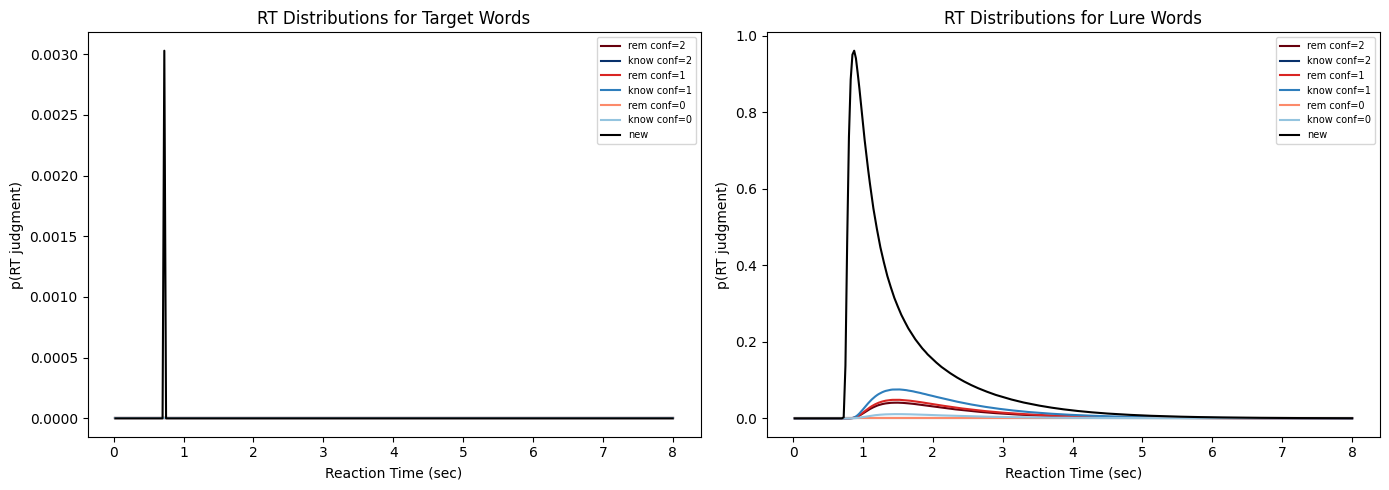

In [20]:
fig, axes = sisp_constrained_lure_model.plot_rt_distributions(params_est, show=False)

results = [
    sisp_constrained_lure_model.evaluate(params_est, method="qmpe", n_params=n_params, n_trials=n_trials),
    sisp_constrained_lure_model.evaluate(params_est, method="qmle", n_params=n_params, n_trials=n_trials),
    sisp_constrained_lure_model.evaluate(params_est, method="cml", n_params=n_params, n_trials=n_trials),
]

display_comparison(results)

### DISP Classic

In [8]:
class DISPClassicLuresOnly(DISPClassicDDM):
    Params = DISPClassicDDM.Params

    def compute_gof_all(self, model_params, data=base_model.DATA, method="qmpe", use_chisq=False):
        """Overrides the base loss function to ONLY compute loss for Lures."""
        try:
            target_params, lure_params = self.split_params(model_params)

            # Only extract the new (lure) data
            new_data = [data.rem_fa.rt, data.know_fa.rt, data.CR.rt, data.rem_fa.conf, data.know_fa.conf]

            # Compute GOF ONLY for the lures
            gof_lure = self.compute_model_gof(lure_params, *new_data, method=method, use_chisq=use_chisq)

            if pl.isnan(gof_lure) or pl.isinf(gof_lure):
                return 1e9
            return gof_lure
        except Exception:
            return 1e9


disp_classic_lure_model = DISPClassicLuresOnly(
    config=caa_cfg,
    nr_threads=1,
)

original_bounds = disp_classic.param_bounds
locked_lower = original_bounds[0]
locked_upper = original_bounds[1]._replace(
    mu_r=locked_lower.mu_r,
    mu_f=locked_lower.mu_f,
)
param_bounds = (locked_lower, locked_upper)

n_params = 10
n_trials = (
    len(data.CR.rt)
    + len(data.rem_fa.rt)
    + len(data.know_fa.rt)
)

# Optimize over entire data (Uncomment to run)
# disp_classic_lure_opt = fit_methods(
#     disp_classic_lure_model,
#     methods,
#     param_bounds=param_bounds,
#     nr_workers=7,
# )

disp_classic_lure_opt = {
    'qmle': DISPClassicLuresOnly.Params(c=np.float64(1.1963720644704954), mu_r=np.float64(-1.8992137285188053), mu_f=np.float64(-1.887565287403501), d_r=np.float64(0.07927202881002127), d_f=np.float64(0.3771286191232043), tc_bound=np.float64(0.02016365637072415), r_bound=np.float64(0.2339964811003736), z0=np.float64(-0.2524874346593893), mu_r_new=np.float64(-0.0759291906436331), mu_f_new=np.float64(-0.17191030090531512), t_post=np.float64(0.4395359900020719), t0=np.float64(0.6624999705139678)),
    'qmpe': DISPClassicLuresOnly.Params(c=np.float64(1.1737101114473565), mu_r=np.float64(-2.0288173751643255), mu_f=np.float64(-1.9561003226015687), d_r=np.float64(0.07467110265083027), d_f=np.float64(0.374441680060155), tc_bound=np.float64(0.022435133527800785), r_bound=np.float64(0.20617481650232322), z0=np.float64(-0.23427059243307974), mu_r_new=np.float64(-0.08569562407850152), mu_f_new=np.float64(-0.17989238655595258), t_post=np.float64(0.43891727730032215), t0=np.float64(0.6473058720106635))
}

method = "qmpe"
params_est = disp_classic_lure_opt[method]


### Model Evaluation Comparison

| Metric | `QMPE` | `QMLE` | `CML` |
| :--- | ---: | ---: | ---: |
| **Trials ($N$)** | 3,886 | 3,886 | 3,886 |
| **Parameters ($k$)** | 10 | 10 | 10 |
| **Negative Log-Likelihood** | 160.56 | 172.04 | 8202.50 |
| **AIC** | **341.12** | **364.08** | **16425.00** |
| **BIC** | **403.77** | **426.73** | **16487.65** |


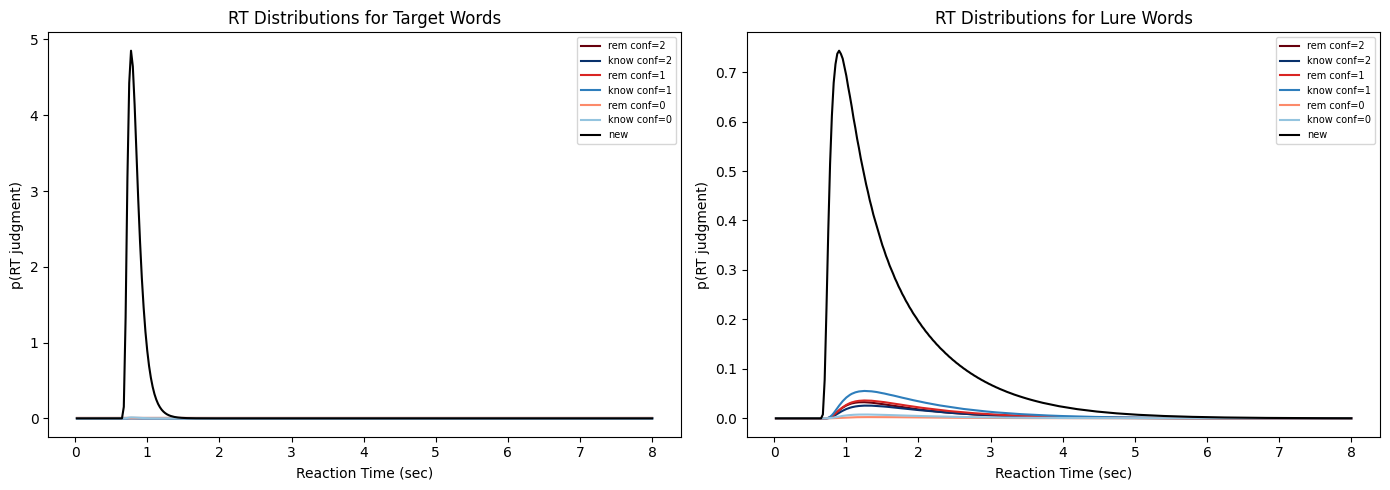

In [9]:
fig, axes = disp_classic_lure_model.plot_rt_distributions(params_est, show=False)
results = [
    disp_classic_lure_model.evaluate(params_est, method="qmpe", n_params=n_params, n_trials=n_trials),
    disp_classic_lure_model.evaluate(params_est, method="qmle", n_params=n_params, n_trials=n_trials),
    disp_classic_lure_model.evaluate(params_est, method="cml", n_params=n_params, n_trials=n_trials),
]

display_comparison(results)

### NLL Analysis

In [10]:
import pylab as pl
method = "qmpe"

# 1. Get the actual human data counts for Lures
n_rem_fa = len(base_model.DATA.rem_fa.rt)
n_know_fa = len(base_model.DATA.know_fa.rt)
n_cr = len(base_model.DATA.CR.rt)
n_total_lures = n_rem_fa + n_know_fa + n_cr

actual_rem_prob = n_rem_fa / n_total_lures
actual_know_prob = n_know_fa / n_total_lures
actual_cr_prob = n_cr / n_total_lures

print("=== ACTUAL HUMAN DATA (LURES) ===")
print(f"Rem False Alarms:  {actual_rem_prob:.3f} ({n_rem_fa} trials)")
print(f"Know False Alarms: {actual_know_prob:.3f} ({n_know_fa} trials)")
print(f"Correct Rejects:   {actual_cr_prob:.3f} ({n_cr} trials)\n")


# 2. Get the SISP Model Predictions
# (Assuming your SISP fit parameters are stored in `sisp_params_est`)
sisp_params_est = sisp_constrained_lure_opt[method]

_, lure_params_sisp = sisp_constrained_lure_model.split_params(sisp_params_est)
p_rem_sisp, p_know_sisp, p_new_sisp, _ = sisp_constrained_lure_model.predicted_proportions(lure_params_sisp)

# Sum the entire probability arrays to get the total mass assigned to each choice
sisp_rem_prob = pl.sum(p_rem_sisp)
sisp_know_prob = pl.sum(p_know_sisp)
sisp_cr_prob = pl.sum(p_new_sisp)

print("=== SISP MODEL PREDICTIONS ===")
print(f"Rem False Alarms:  {sisp_rem_prob:.3f}")
print(f"Know False Alarms: {sisp_know_prob:.3f}")
print(f"Correct Rejects:   {sisp_cr_prob:.3f}\n")


# 3. Get the DISP Model Predictions
disp_params_est = disp_classic_lure_opt[method]

_, lure_params_disp = disp_classic_lure_model.split_params(disp_params_est)
p_rem_disp, p_know_disp, p_new_disp, _ = disp_classic_lure_model.predicted_proportions(lure_params_disp)

disp_rem_prob = pl.sum(p_rem_disp)
disp_know_prob = pl.sum(p_know_disp)
disp_cr_prob = pl.sum(p_new_disp)

print("=== DISP MODEL PREDICTIONS ===")
print(f"Rem False Alarms:  {disp_rem_prob:.3f}")
print(f"Know False Alarms: {disp_know_prob:.3f}")
print(f"Correct Rejects:   {disp_cr_prob:.3f}")

=== ACTUAL HUMAN DATA (LURES) ===
Rem False Alarms:  0.116 (451 trials)
Know False Alarms: 0.149 (579 trials)
Correct Rejects:   0.735 (2856 trials)

=== SISP MODEL PREDICTIONS ===
Rem False Alarms:  0.109
Know False Alarms: 0.105
Correct Rejects:   0.781

=== DISP MODEL PREDICTIONS ===
Rem False Alarms:  0.107
Know False Alarms: 0.141
Correct Rejects:   0.746


In [11]:
import pylab as pl
import numpy as np

method = "qmpe"

# Helper function to get empirical probabilities by confidence from actual data
def get_conf_probs(data_conf_array, total_n):
    if len(data_conf_array) == 0:
        return {}
    unique_confs, counts = np.unique(data_conf_array, return_counts=True)
    return {int(conf): count / total_n for conf, count in zip(unique_confs, counts)}

# --- 1. ACTUAL HUMAN DATA ---
n_total_lures = len(base_model.DATA.rem_fa.rt) + len(base_model.DATA.know_fa.rt) + len(base_model.DATA.CR.rt)

actual_rem_conf = get_conf_probs(base_model.DATA.rem_fa.conf, n_total_lures)
actual_know_conf = get_conf_probs(base_model.DATA.know_fa.conf, n_total_lures)
actual_cr_prob = len(base_model.DATA.CR.rt) / n_total_lures


# --- 2. SISP MODEL PREDICTIONS ---
sisp_params_est = sisp_constrained_lure_opt[method]
_, lure_params_sisp = sisp_constrained_lure_model.split_params(sisp_params_est)
p_rem_sisp, p_know_sisp, p_new_sisp, _ = sisp_constrained_lure_model.predicted_proportions(lure_params_sisp)

sisp_rem_conf = pl.sum(p_rem_sisp, axis=1)
sisp_know_conf = pl.sum(p_know_sisp, axis=1)
sisp_cr_prob = pl.sum(p_new_sisp)


# --- 3. DISP MODEL PREDICTIONS ---
disp_params_est = disp_classic_lure_opt[method]
_, lure_params_disp = disp_classic_lure_model.split_params(disp_params_est)
p_rem_disp, p_know_disp, p_new_disp, _ = disp_classic_lure_model.predicted_proportions(lure_params_disp)

disp_rem_conf = pl.sum(p_rem_disp, axis=1)
disp_know_conf = pl.sum(p_know_disp, axis=1)
disp_cr_prob = pl.sum(p_new_disp)


# --- 4. PRINT FORMATTED TABLE ---
print(f"{'Category':<22} | {'Human Actual':<15} | {'SISP Predicted':<15} | {'DISP Predicted':<15}")
print("-" * 75)
print(f"{'Correct Rejects':<22} | {actual_cr_prob:<15.4f} | {sisp_cr_prob:<15.4f} | {disp_cr_prob:<15.4f}")

# Map Conf 2 -> Bin 1 (Index 0), Conf 1 -> Bin 2 (Index 1), Conf 0 -> Bin 3 (Index 2)
for i in range(3):
    conf_level = 2 - i
    h_rem = actual_rem_conf.get(conf_level, 0.0)
    label = f"Rem Conf {conf_level} (Bin {i+1})"
    print(f"{label:<22} | {h_rem:<15.4f} | {sisp_rem_conf[i]:<15.4f} | {disp_rem_conf[i]:<15.4f}")
    
for i in range(3):
    conf_level = 2 - i
    h_know = actual_know_conf.get(conf_level, 0.0)
    label = f"Know Conf {conf_level} (Bin {i+1})"
    print(f"{label:<22} | {h_know:<15.4f} | {sisp_know_conf[i]:<15.4f} | {disp_know_conf[i]:<15.4f}")

Category               | Human Actual    | SISP Predicted  | DISP Predicted 
---------------------------------------------------------------------------
Correct Rejects        | 0.7349          | 0.7811          | 0.7461         
Rem Conf 2 (Bin 1)     | 0.0502          | 0.0502          | 0.0466         
Rem Conf 1 (Bin 2)     | 0.0587          | 0.0584          | 0.0561         
Rem Conf 0 (Bin 3)     | 0.0072          | 0.0000          | 0.0044         
Know Conf 2 (Bin 1)    | 0.0422          | 0.0000          | 0.0415         
Know Conf 1 (Bin 2)    | 0.0916          | 0.0916          | 0.0874         
Know Conf 0 (Bin 3)    | 0.0152          | 0.0130          | 0.0123         


In [12]:
import numpy as np

# Helper to map confidence to your data
def get_bin_counts(data_conf_array):
    counts_dict = {0: 0, 1: 0, 2: 0}
    if len(data_conf_array) > 0:
        unique, counts = np.unique(data_conf_array, return_counts=True)
        for u, c in zip(unique, counts):
            counts_dict[int(u)] = c
    return [counts_dict[2], counts_dict[1], counts_dict[0]] # Conf 2, 1, 0

n_cr = len(base_model.DATA.CR.rt)
rem_counts = get_bin_counts(base_model.DATA.rem_fa.conf)
know_counts = get_bin_counts(base_model.DATA.know_fa.conf)

def get_penalty(count, prob):
    # Use your exact EPS from your config (1e-10) to cap the penalty exactly like QMPE does
    safe_p = max(prob, 1e-10) 
    return -count * np.log(safe_p)

print("=== PURE NLL PENALTY PER CATEGORY (Lower is Better) ===")
print(f"{'Category':<15} | {'Trials':<8} | {'SISP Penalty':<14} | {'DISP Penalty':<14} | {'DISP Net Gain'}")
print("-" * 75)

# 1. Correct Rejections
s_pen = get_penalty(n_cr, sisp_cr_prob)
d_pen = get_penalty(n_cr, disp_cr_prob)
print(f"{'Correct Rejects':<15} | {n_cr:<8} | {s_pen:<14.1f} | {d_pen:<14.1f} | {s_pen - d_pen:>+10.1f}")

# 2. Remember False Alarms
for i in range(3):
    count = rem_counts[i]
    s_pen = get_penalty(count, sisp_rem_conf[i])
    d_pen = get_penalty(count, disp_rem_conf[i])
    print(f"Rem Conf {2-i:<6} | {count:<8} | {s_pen:<14.1f} | {d_pen:<14.1f} | {s_pen - d_pen:>+10.1f}")

# 3. Know False Alarms
for i in range(3):
    count = know_counts[i]
    s_pen = get_penalty(count, sisp_know_conf[i])
    d_pen = get_penalty(count, disp_know_conf[i])
    print(f"Know Conf {2-i:<5} | {count:<8} | {s_pen:<14.1f} | {d_pen:<14.1f} | {s_pen - d_pen:>+10.1f}")

=== PURE NLL PENALTY PER CATEGORY (Lower is Better) ===
Category        | Trials   | SISP Penalty   | DISP Penalty   | DISP Net Gain
---------------------------------------------------------------------------
Correct Rejects | 2856     | 705.7          | 836.4          |     -130.7
Rem Conf 2      | 195      | 583.4          | 597.8          |      -14.3
Rem Conf 1      | 228      | 647.6          | 656.9          |       -9.3
Rem Conf 0      | 28       | 644.7          | 151.9          |     +492.8
Know Conf 2     | 164      | 3776.2         | 522.0          |    +3254.2
Know Conf 1     | 356      | 850.8          | 867.8          |      -17.0
Know Conf 0     | 59       | 256.3          | 259.4          |       -3.1
